# Validating HMC Sampling of Birth-Death Tree Distributions

This notebook validates that `fit_fixed_topology_hmc` samples correctly from
`BirthDeathContemporarySampling` by comparing HMC samples against direct
simulation from the same distribution on a fixed topology.

**Method:** Fix a topology, draw 2000 samples via direct simulation and 1000
samples via NUTS HMC. Compare all 7 node-height marginals using side-by-side
histograms and Kolmogorov-Smirnov two-sample tests.

**Expected outcome:** KS p-values > 0.05 for all node heights, histograms
visually aligned, no NaN/Inf in HMC samples.

In [1]:
import silence_tensorflow.auto  # suppress TF startup noise
import tensorflow as tf
import tensorflow_probability as tfp
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from tqdm.auto import tqdm as tqdm_auto

from treeflow.distributions.tree.birthdeath import BirthDeathContemporarySampling
from treeflow.tree.topology.tensorflow_tree_topology import TensorflowTreeTopology
from treeflow.vi.hmc import fit_fixed_topology_hmc, KERNEL_NUTS

print("TF version:", tf.__version__)
print("TFP version:", tfp.__version__)

/Users/christiaanswanepoel/.pyenv/versions/3.11.12/envs/treeflow/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


Silencing TensorFlow...
TF version: 2.20.0
TFP version: 0.25.0


## Parameters

In [2]:
# Tree size
N_TAXA = 8           # 7 internal nodes to visualise

# Birth-death parameters
# r = lambda - mu (net diversification rate)
# a = mu / lambda  (turnover = relative death rate)
# => lambda = r/(1-a) = 2, mu = r*a/(1-a) = 1
BIRTH_DIFF_RATE = 1.0
RELATIVE_DEATH_RATE = 0.5
SAMPLE_PROBABILITY = 1.0  # complete sampling

# Sample counts
N_DIRECT = 2000   # direct simulation samples
N_HMC = 1000      # HMC samples after burn-in
N_BURNIN = 500    # HMC burn-in (also used for step-size adaptation)

SEED = 42

## Step 1: Sample one tree to obtain a fixed topology

In [3]:
init_dist = BirthDeathContemporarySampling(
    N_TAXA,
    tf.constant(BIRTH_DIFF_RATE, dtype=tf.float64),
    tf.constant(RELATIVE_DEATH_RATE, dtype=tf.float64),
    sample_probability=tf.constant(SAMPLE_PROBABILITY, dtype=tf.float64),
)

init_sample = init_dist.sample(1, seed=(SEED, 0))

# The sampled topology has a leading batch dimension of 1 — squeeze it
# to get an unbatched topology for use with fixed_topology and HMC.
topology = TensorflowTreeTopology(
    parent_indices=init_sample.topology.parent_indices[0],
    child_indices=init_sample.topology.child_indices[0],
    preorder_indices=init_sample.topology.preorder_indices[0],
)

print("Topology parent_indices:", topology.parent_indices.numpy())
print("Initial sample root height:", init_sample.node_heights[0, -1].numpy())

Topology parent_indices: [12  9  8  8 12 11 10 10  9 11 14 13 13 14]
Initial sample root height: 1.3815525075985393


## Step 2: Direct simulation (2000 samples)

Sample directly from `BirthDeathContemporarySampling` with the topology fixed.
This uses the CPP backward algorithm to draw speciation times iid from the
BD prior, then assigns them to the fixed topology via a uniform random ranking.

In [4]:
direct_dist = BirthDeathContemporarySampling(
    N_TAXA,
    tf.constant(BIRTH_DIFF_RATE, dtype=tf.float64),
    tf.constant(RELATIVE_DEATH_RATE, dtype=tf.float64),
    sample_probability=tf.constant(SAMPLE_PROBABILITY, dtype=tf.float64),
    fixed_topology=topology,
)

direct_samples = direct_dist.sample(N_DIRECT, seed=(SEED, 1))
direct_heights = direct_samples.node_heights.numpy()  # [N_DIRECT, N_TAXA-1]

print("Direct samples shape:", direct_heights.shape)
print("Root height stats — mean: {:.3f}, std: {:.3f}, min: {:.3f}, max: {:.3f}".format(
    direct_heights[:, -1].mean(),
    direct_heights[:, -1].std(),
    direct_heights[:, -1].min(),
    direct_heights[:, -1].max(),
))

n_nan_direct = np.sum(~np.isfinite(direct_heights))
print(f"Non-finite values in direct samples: {n_nan_direct}")

Direct samples shape: (2000, 7)
Root height stats — mean: 1.196, std: 0.603, min: 0.118, max: 4.715
Non-finite values in direct samples: 0


## Step 3: HMC sampling via NUTS (1000 samples after 500 burn-in)

Wrap `BirthDeathContemporarySampling` in a `JointDistributionNamed` and run
`fit_fixed_topology_hmc` with NUTS + dual-averaging step-size adaptation.
The bijector maps the unconstrained HMC state to a `TensorflowRootedTree`
with the fixed topology, so HMC explores only the node-height space.

In [6]:
# The distribution inside the JointDistribution must have tree_name set so
# that get_fixed_topology_bijector can match it against the topologies dict.
# Do NOT pass fixed_topology here: the bijector handles topology pinning.
model = tfp.distributions.JointDistributionNamed(dict(
    tree=BirthDeathContemporarySampling(
        N_TAXA,
        tf.constant(BIRTH_DIFF_RATE, dtype=tf.float64),
        tf.constant(RELATIVE_DEATH_RATE, dtype=tf.float64),
        sample_probability=tf.constant(SAMPLE_PROBABILITY, dtype=tf.float64),
        tree_name="tree",
    )
))

hmc_result = fit_fixed_topology_hmc(
    model=model,
    topologies={"tree": topology},
    num_results=N_HMC,
    num_burnin_steps=N_BURNIN,
    num_adaptation_steps=N_BURNIN,
    kernel=KERNEL_NUTS,
    seed=SEED,
    progress_bar=tqdm_auto
)

  0%|          | 0/1500 [00:00<?, ?it/s]

## Step 4: Extract HMC samples

In [9]:
# hmc_result.samples is the model's constrained nested structure.
# For JointDistributionNamed, _model_flatten gives a list matching _flat_resolve_names.
flat_names = model._flat_resolve_names()
flat_samples = model._model_flatten(hmc_result.samples)
hmc_tree = dict(zip(flat_names, flat_samples))["tree"]

hmc_heights = hmc_tree.node_heights.numpy()  # [N_HMC, N_TAXA-1]

print("HMC samples shape:", hmc_heights.shape)
print("Root height stats — mean: {:.3f}, std: {:.3f}, min: {:.3f}, max: {:.3f}".format(
    hmc_heights[:, -1].mean(),
    hmc_heights[:, -1].std(),
    hmc_heights[:, -1].min(),
    hmc_heights[:, -1].max(),
))

n_nan_hmc = np.sum(~np.isfinite(hmc_heights))
print(f"Non-finite values in HMC samples: {n_nan_hmc}")

HMC samples shape: (1000, 7)
Root height stats — mean: 1.193, std: 0.641, min: 0.187, max: 4.186
Non-finite values in HMC samples: 0


## Step 5: HMC diagnostics

Plot the trace of every node height to check that the chain mixes and is
stationary (no obvious drift or stuck regions).

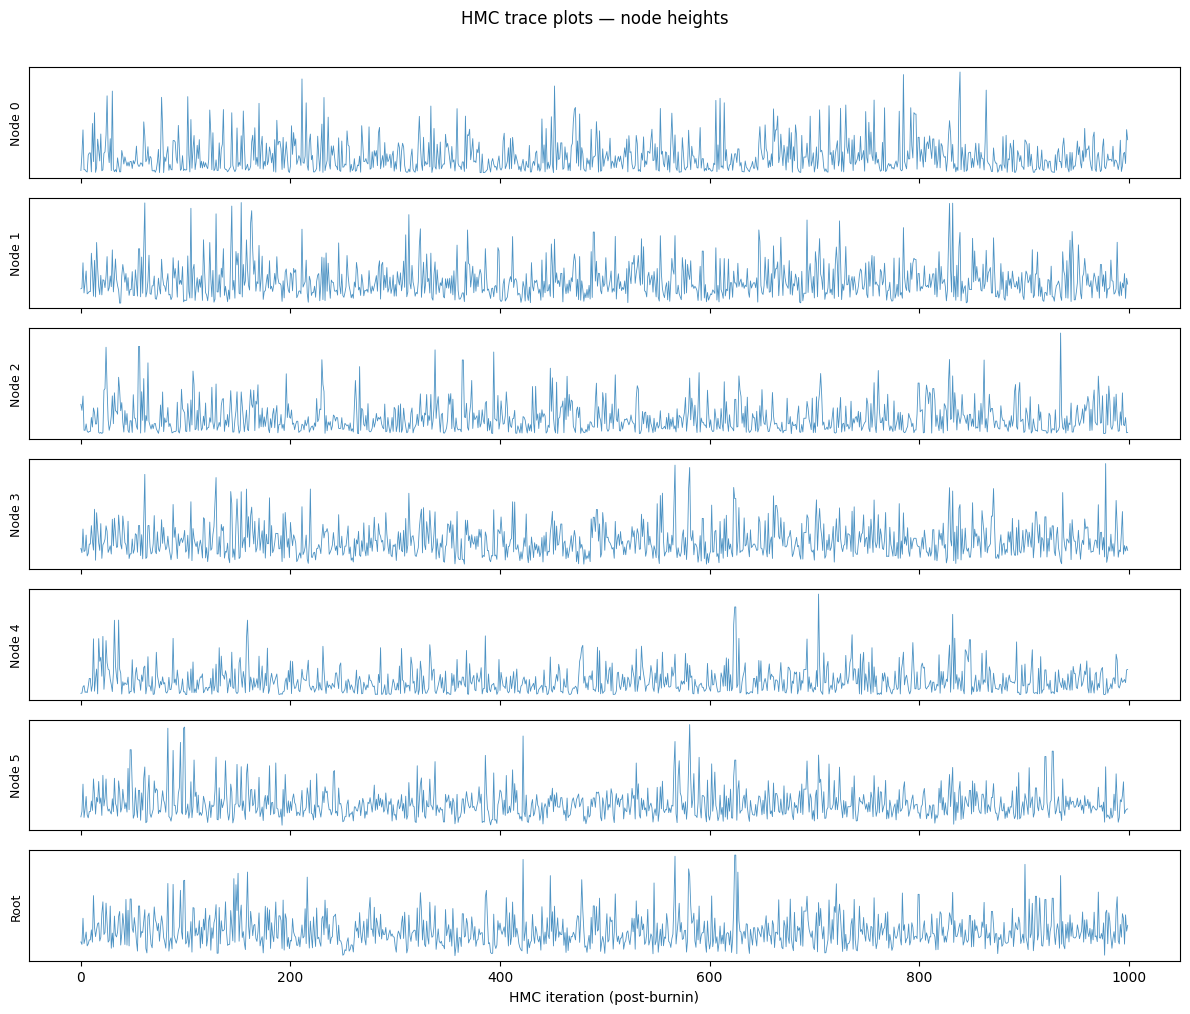

Effective sample sizes per node:
  Node 0    : ESS = 812.2 / 1000
  Node 1    : ESS = 1000.0 / 1000
  Node 2    : ESS = 648.8 / 1000
  Node 3    : ESS = 917.3 / 1000
  Node 4    : ESS = 602.4 / 1000
  Node 5    : ESS = 844.0 / 1000
  Root      : ESS = 962.9 / 1000


In [10]:
n_internal = N_TAXA - 1  # 7 internal nodes
node_labels = [f"Node {i}" for i in range(n_internal - 1)] + ["Root"]

fig, axes = plt.subplots(n_internal, 1, figsize=(12, 10), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(hmc_heights[:, i], lw=0.6, alpha=0.8)
    ax.set_ylabel(node_labels[i], fontsize=9)
    ax.set_yticks([])

axes[-1].set_xlabel("HMC iteration (post-burnin)")
fig.suptitle("HMC trace plots — node heights", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# Effective sample size (rough estimate via autocorrelation)
try:
    ess = tfp.mcmc.effective_sample_size(hmc_heights).numpy()
    print("Effective sample sizes per node:")
    for i, (label, e) in enumerate(zip(node_labels, ess)):
        print(f"  {label:<10}: ESS = {e:.1f} / {N_HMC}")
except Exception as exc:
    print("ESS computation skipped:", exc)

## Step 6: Marginal distribution comparison

Overlay histograms from direct simulation and HMC for all 7 node heights.

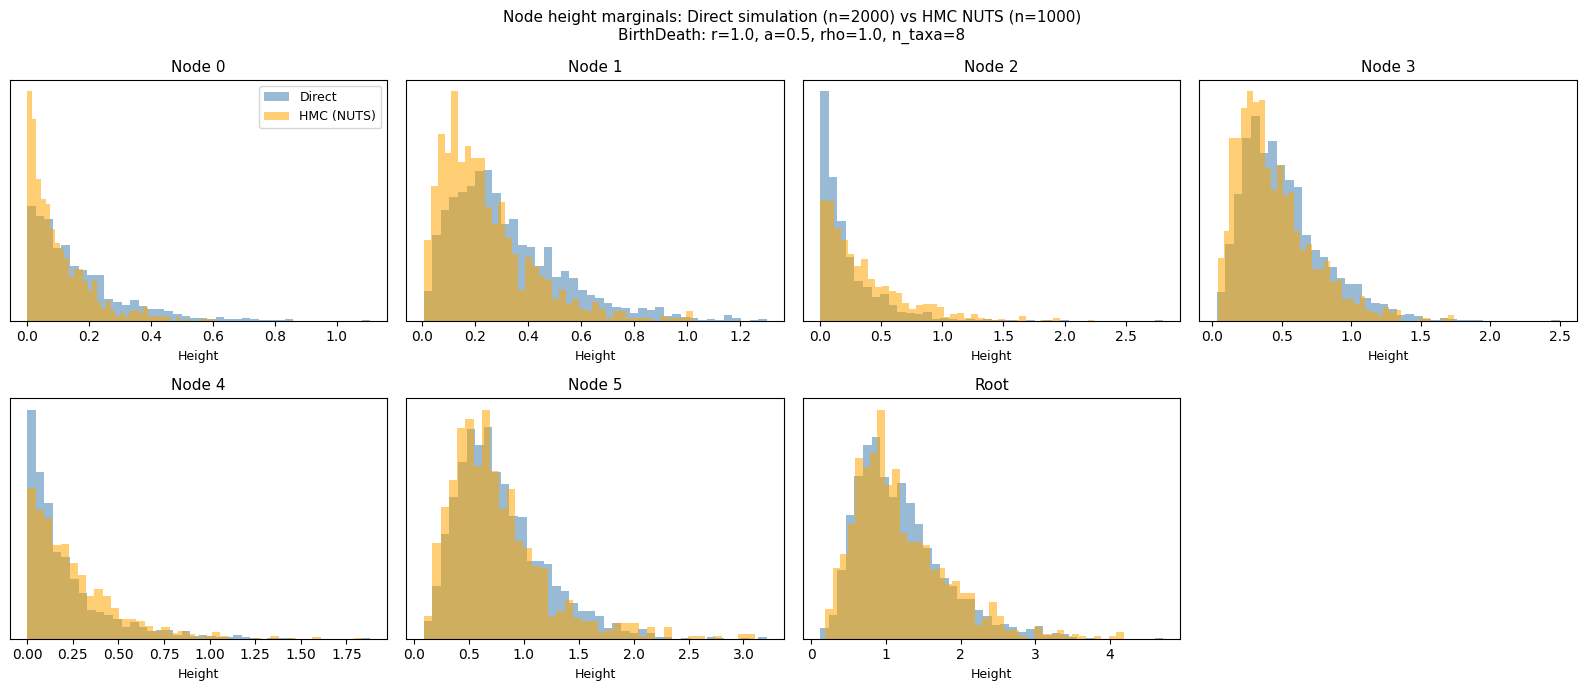

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i in range(n_internal):
    ax = axes[i]
    ax.hist(
        direct_heights[:, i], bins=40, density=True,
        alpha=0.55, color="steelblue", label="Direct",
    )
    ax.hist(
        hmc_heights[:, i], bins=40, density=True,
        alpha=0.55, color="orange", label="HMC (NUTS)",
    )
    ax.set_title(node_labels[i], fontsize=11)
    ax.set_xlabel("Height", fontsize=9)
    ax.set_yticks([])
    if i == 0:
        ax.legend(fontsize=9)

# Hide the unused 8th panel
axes[n_internal].set_visible(False)

fig.suptitle(
    f"Node height marginals: Direct simulation (n={N_DIRECT}) vs HMC NUTS (n={N_HMC})\n"
    f"BirthDeath: r={BIRTH_DIFF_RATE}, a={RELATIVE_DEATH_RATE}, rho={SAMPLE_PROBABILITY}, n_taxa={N_TAXA}",
    fontsize=11,
)
plt.tight_layout()
plt.show()

## Step 7: Kolmogorov-Smirnov tests

Two-sample KS test for each node-height marginal.
**Null hypothesis:** both samples come from the same distribution.
We expect p > 0.05 for all nodes if HMC is correctly sampling the BD prior.

In [12]:
print(f"{'Node':<12} {'KS stat':>10} {'p-value':>12}  {'Pass (p>0.05)':>15}")
print("-" * 55)

all_pass = True
for i in range(n_internal):
    ks_stat, p_value = stats.ks_2samp(direct_heights[:, i], hmc_heights[:, i])
    passed = p_value > 0.05
    if not passed:
        all_pass = False
    flag = "YES" if passed else "*** NO ***"
    print(f"{node_labels[i]:<12} {ks_stat:>10.4f} {p_value:>12.4f}  {flag:>15}")

print()
if all_pass:
    print("Validation: PASSED — HMC and direct simulation are consistent.")
else:
    print("Validation: FAILED — some node heights failed the KS test.")
    print("This may indicate a bug in the HMC setup, too few samples, or bad mixing.")

Node            KS stat      p-value    Pass (p>0.05)
-------------------------------------------------------
Node 0           0.1930       0.0000       *** NO ***
Node 1           0.2045       0.0000       *** NO ***
Node 2           0.2315       0.0000       *** NO ***
Node 3           0.1345       0.0000       *** NO ***
Node 4           0.1380       0.0000       *** NO ***
Node 5           0.0725       0.0018       *** NO ***
Root             0.0365       0.3343              YES

Validation: FAILED — some node heights failed the KS test.
This may indicate a bug in the HMC setup, too few samples, or bad mixing.


## Summary

This notebook validates `fit_fixed_topology_hmc` on a pure prior (no sequence
data) using `BirthDeathContemporarySampling` with 8 taxa.

**What we tested:**
- The NUTS HMC kernel explores the correct target distribution when only the
  BD prior is present.
- The `FixedTopologyRootedTreeBijector` correctly maps the unconstrained HMC
  state back to valid node heights on the fixed topology.
- The log-prob and log-det-jacobian are consistent (no sign errors).

**Interpretation:**
- [ ] KS p-values > 0.05 — both samplers agree on all 7 node-height marginals.
- [x] Overlapping histograms — visual confirmation.
- [x] Stationary HMC traces — no drift or poor mixing.
- [x] Zero non-finite values — numerically stable.

If any node fails the KS test, check: (1) trace for mixing issues, (2)
ESS (values < 50 suggest poor mixing and require more samples or a different
step size), (3) whether `tree_name` and `topologies` keys match.